<a href="https://colab.research.google.com/github/davidsjohnson/blockies-xai/blob/iui2026-xai/blockies_v2_xai_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Blockies Dataset

This notebook is to act as a template for generating XAI approaches on the new and updated Blockies dataset. The datasets downloaded in this notebook will be the final datasets for the IUI2026 User Study.

There are two dataset to generate explanations for.  The *Main Study Dataset* which will be the dataset use to perform the main part of the study.  And the *Tutorial Dataset* which will be used in the tutorial portion of the study.  

In [2]:
import pathlib
import os
import sys
from pathlib import Path
import tarfile
import random
import zipfile

import numpy as np

import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
CLASSES = ['Healthy', 'OCDegen']

modeltype = 'resnet18'

# Setup and Load Datasets

In [4]:
# data downloading and dataset utilities

def download_file(url, file_name, cache_dir="data", extract=True, force_download=False, archive_folder=None):
    # Ensure the cache directory exists
    os.makedirs(cache_dir, exist_ok=True)
    file_path = os.path.join(cache_dir, file_name)

    # Download the file
    if not os.path.exists(file_path) or force_download:
      torch.hub.download_url_to_file(url, file_path)
      print(f"File downloaded to: {file_path}")
    else:
      print(f"File already exists at: {file_path}")

    if extract:
      if file_path.endswith(".tar.gz"):
        print("Extracting tar.gz file...")
        with tarfile.open(file_path, "r:gz") as tar:
            tar.extractall(path=cache_dir)
      elif file_path.endswith(".zip"):
        print("Extracting zip file...")
        with zipfile.ZipFile(file_path, 'r') as zip_ref:
            zip_ref.extractall(cache_dir)
      else:
        raise ValueError("Unsupported file format. Only .tar.gz and .zip files are supported.")

      print(f"File extracted to: {cache_dir}")
      return Path(cache_dir) / archive_folder if archive_folder is not None else Path(cache_dir)

    return Path(file_path)

class ImageDataset(Dataset):
    def __init__(self, df, data_dir, transform=None):
        self.df = df
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = os.path.join(self.data_dir, self.df.iloc[idx]['filename'])
        image = Image.open(img_path).convert('RGB')
        label = int(self.df.iloc[idx]['ill'])

        if self.transform:
            image = self.transform(image)

        return image, label

## Load Dataset and Dataloaders


## Load XAI Study Data

In [5]:
import ast
def convert_string_list_to_list(df, column_name):
    df[column_name] = df[column_name].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    return df

In [6]:
study_zip = 'https://uni-bielefeld.sciebo.de/s/MlRrDyzD0GKOK67/download'
zip_name = 'study_samples'

study_dir = download_file(url=study_zip,
                          file_name=f"{zip_name}.zip",
                          cache_dir='data', # change this if not using Colab
                          extract=True,
                          force_download=True,
                          archive_folder=zip_name)
study_dir

100%|██████████| 7.81M/7.81M [00:00<00:00, 11.0MB/s]


File downloaded to: data/study_samples.zip
Extracting zip file...
File extracted to: data


PosixPath('data/study_samples')

In [7]:
# load and preprocess dataframes
main_dir = study_dir / 'main_data/xai_samples'
tutorial_dir = study_dir / 'tutorial_data/xai_samples'

study_df = pd.read_csv(main_dir / 'xai_samples_df.csv')
study_df = convert_string_list_to_list(study_df, 'ill_chars')
study_df['ill_label'] = study_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
study_df['pred_label'] = study_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})

tutorial_df = pd.read_csv(tutorial_dir / 'xai_samples_df.csv')
tutorial_df = convert_string_list_to_list(tutorial_df, 'ill_chars')
tutorial_df['ill_label'] = tutorial_df['ill'].astype(int).map({0: 'Healthy', 1: 'OCDegen'})
tutorial_df['pred_label'] = tutorial_df['pred'].astype(int).map({0: 'Healthy', 1: 'OC Degen'})

In [8]:
# blockies v2 - 2 class dataset
mean = [0.8258, 0.8043, 0.8164]
std = [0.0768, 0.0835, 0.0904]


transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=mean, std=std)
])


study_dataset = ImageDataset(study_df, main_dir, transform=transform)
study_dataloader = DataLoader(study_dataset, batch_size=1, shuffle=False,
                              num_workers=6, pin_memory=True)

tutorial_dataset = ImageDataset(tutorial_df, tutorial_dir, transform=transform)
tutorial_dataloader = DataLoader(tutorial_dataset, batch_size=1, shuffle=False,
                                 num_workers=6, pin_memory=True)

# Model Loading and Evaluation





In [9]:
def load_resnet18(num_classes, pretrained=True, checkpoint_path=None):
  model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT if pretrained else None)
  model.fc = nn.Linear(model.fc.in_features, num_classes)
  print("Loaded random model")

  if checkpoint_path:
      checkpoint = torch.load(checkpoint_path, map_location='cpu')
      model.load_state_dict(checkpoint)
      print(f"Loaded checkpoint from: {checkpoint_path}")

  return model

In [10]:
def set_seed(seed):
  """
  Sets random seeds for reproducibility.
  """
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
  torch.backends.cudnn.deterministic = True
  torch.backends.cudnn.benchmark = False


def evaluate_model(model, dataloader, criterion, device):
    model.eval()  # Set model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    preds = []
    with torch.no_grad():  # Disable gradient calculation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Track loss and accuracy
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            preds.extend(predicted.cpu().numpy())
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(dataloader)
    accuracy = correct / total

    print(f"Evaluation Loss: {avg_loss:.4f}, Evaluation Accuracy: {accuracy:.4f}")
    return avg_loss, accuracy, np.array(preds)

In [11]:
checkpoint_path = download_file(url='https://uni-bielefeld.sciebo.de/s/J2d1z9V5wQGGR8X/download',
                                file_name='best_model.pth',
                                cache_dir=f'model/{modeltype}_checkpoint', # change this if not using Colab
                                extract=False,
                                force_download=False)
checkpoint_path

File already exists at: model/resnet18_checkpoint/best_model.pth


PosixPath('model/resnet18_checkpoint/best_model.pth')

In [12]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Check predictions on datasets

Sanity check to ensure the model is the correct one

- The main study dataset should have 80% accuracy.
- The tutorial dataset should have 60% accuracy.

In [13]:
# load best model and evaluate
model = load_resnet18(num_classes=len(CLASSES),
                      pretrained=False,
                      checkpoint_path=checkpoint_path)
model.to(device)

_, _, study_preds = evaluate_model(model, study_dataloader, criterion, device)
_, _, tutorial_preds = evaluate_model(model, tutorial_dataloader, criterion, device)

Loaded random model
Loaded checkpoint from: model/resnet18_checkpoint/best_model.pth
Evaluation Loss: 0.6064, Evaluation Accuracy: 0.8000
Evaluation Loss: 0.9999, Evaluation Accuracy: 0.6000


In [14]:
# compare to saved accuracies
(study_df['pred'] == study_df['ill']).mean(), (tutorial_df['pred'] == tutorial_df['ill']).mean()

(0.8, 0.6)

In [15]:
# assert that all predictions are the same
assert (study_preds == study_df['pred']).all(), 'Study predictions are incorrect'
assert (tutorial_preds == tutorial_df['pred']).all(), 'Tutorial predictions are incorrect '

print('All predictions for each dataset are equal. This is the correct model')

All predictions for each dataset are equal. This is the correct model


# View Data

In [16]:
# display the widest dataframe
# This will show all columns of the DataFrame without truncation
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
study_df.head(2) 

,Unnamed: 0,obj_name,num_ill_chars,ill_chars,labeling_error,main_spherical,sec_spherical,sec_bones,bending,obj_rotation_roll,obj_rotation_pitch,obj_rotation_yaw,fliplr,position_x,position_y,arm_position,obj_color,obj_color_rgba,bg_color,bg_color_rgba,resolution,id,original_id,_attributes_status,label,__module__,__name__,filename,ill,sphere_diff,num_sec_bones,pred,main_spherical_pred,sec_spherical_pred,bending_pred,arm_position_pred,num_sec_bones_pred,obj_rotation_roll_pred,obj_rotation_pitch_pred,obj_rotation_yaw_pred,position_x_pred,position_y_pred,obj_color_pred,bg_color_pred,concept_pred,ill_label,pred_label
0,320,healthy,0,[],False,0.013151,0.343460,110,0.012181,0.344598,-0.511440,-2.008321,False,-0.697111,-0.651274,0.355950,0.246182,"[0.5488761722823521, 0.6851035851764701, 0.994...",0.834853,"[0.9057834780117641, 0.45518569216470506, 0.35...","[256, 256]",cec708b5-2af1-454b-a0c8-8c8047565127,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",healthy,blockies.scene_parameters,SceneParameters,cec708b5-2af1-454b-a0c8-8c8047565127.png,0,0.330310,2,0,0.048011,0.324341,0.020773,0.349298,2.069187,0.012781,-0.495818,-1.985869,-0.716843,-0.620908,0.226300,0.847573,0,Healthy,Healthy
1,1022,healthy,1,[stretchy],False,0.057501,0.438306,110,0.087594,-0.292657,0.623956,-0.933327,False,-0.745413,-0.725040,0.532666,0.316982,"[0.6461128107647051, 0.764436496529411, 0.9968...",0.440212,"[0.8006008472941171, 0.8503583215607841, 0.930...","[256, 256]",33f21483-6240-4fd5-95bc-36be485b3259,NaN,"{'obj_name': 'sampled', 'num_ill_chars': 'samp...",healthy,blockies.scene_parameters,SceneParameters,33f21483-6240-4fd5-95bc-36be485b3259.png,0,0.380805,2,0,0.090473,0.435559,0.103601,0.455025,1.975521,-0.010562,0.513205,-0.798173,-0.729212,-0.609363,0.325815,0.454940,0,Healthy,Healthy


In [19]:
# Get the unique values in the 'ill_chars' column
unique_ill_chars = study_df['ill_chars'].explode().unique()
print("Unique values in 'ill_chars':", unique_ill_chars)

ill = study_df['ill'].explode().unique()
print("Unique values in 'ill':", ill)

Unique values in 'ill_chars': [nan 'stretchy' 'high_sphere_diff' 'high_bend' 'mutation_mainbones']
Unique values in 'ill': [0 1]


## Main Study Dataset

In [20]:
study_img_paths = study_df['filename'].apply(lambda x: os.path.join(main_dir, x)).tolist()
tutorial_img_paths = tutorial_df['filename'].apply(lambda x: os.path.join(tutorial_dir, x)).tolist()

study_imgs = [Image.open(path).convert('RGB') for path in study_img_paths]
tutorial_imgs = [Image.open(path).convert('RGB') for path in tutorial_img_paths]

# Generate Explanations

### 1- Similarity-based XAI

Given an input image of interest, the similarity explanation method used here aims to find images in the training dataset that are similar to the image of interest according to “how the model sees them”, meaning that the similarity metric makes use of the gradients of the model’s loss function with respect to the model’s parameters. The explanation should be interpreted along the line of “I classify this image as a 1 because I find it similar to another image in the training set that was labeled as a 1.”

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torchvision.models as models
import torch.nn.functional as F
from torch.nn import CrossEntropyLoss
from sklearn.metrics import accuracy_score
from torch.nn.functional import cross_entropy
from alibi.explainers import GradientSimilarity

In [22]:
# Define inverse normalization using training stats
mean = [0.8068, 0.7830, 0.8005]
std = [0.1093, 0.1136, 0.1029]

inv_normalize = T.Normalize(
    mean=[-m/s for m, s in zip(mean, std)],
    std=[1/s for s in std]
)
# Convert tensor to numpy image after inverse normalization
def tensor_to_image(tensor):
    if isinstance(tensor, np.ndarray):
        tensor = torch.tensor(tensor)
    tensor = inv_normalize(tensor)
    tensor = torch.clamp(tensor, 0, 1)
    return tensor.permute(1, 2, 0).cpu().numpy()

In [23]:
def predict_fn(x: np.ndarray) -> np.ndarray:
    model.eval()
    with torch.no_grad():
        x_tensor = torch.tensor(x).to(device)
        logits = model(x_tensor)
    return logits.cpu().numpy()

# Loss function wrapper for Alibi (must take logits and one-hot labels)
def loss_fn(logits: torch.Tensor, labels: torch.Tensor) -> torch.Tensor:
    #print(logits)
    return cross_entropy(logits, labels.argmax(dim=1))

In [24]:
study_dataset

In [25]:
# Use a subset of train dataset as reference
ref_loader = DataLoader(study_dataset, batch_size=20, shuffle=True) #Please change the batch size to 1000
x_ref, y_ref = next(iter(ref_loader))
x_ref = x_ref[:20].numpy().astype('float32')
y_ref = F.one_hot(y_ref[:20], num_classes=len(CLASSES)).numpy().astype('float32')

# Use a few test samples
x_query, y_query = next(iter(study_dataloader))
x_query = x_query[:4].numpy().astype('float32')
y_query = F.one_hot(y_query[:4], num_classes=len(CLASSES)).numpy().astype('float32')

In [26]:
explainer = GradientSimilarity(
    model.cpu(),
    loss_fn=loss_fn,
    sim_fn= "grad_asym_dot",    #### Add another similarity function here if you want to
                                  # get the dissimlarity: file name is gradientsimialrity_1.py and the file metrics.py  
    backend='pytorch',
    task='classification',
    precompute_grads=True
)
explainer

GradientSimilarity(meta={
  'name': 'GradientSimilarity',
  'type': ['whitebox'],
  'explanations': ['local'],
  'params': {
              'sim_fn_name': 'grad_asym_dot',
              'store_grads': True,
              'backend_name': 'pytorch',
              'task_name': 'classification'}
            ,
  'version': '0.9.6'}
)

In [27]:
explainer.fit(x_ref, y_ref)

explanation = explainer.explain(x_query, y_query)

In [28]:
# most similar reference indices for each query
print(explanation.data['ordered_indices'])  # shape: (n_query, n_ref)

# similarity scores
print(explanation.data['scores'])           # shape: (n_query, n_ref)

# top-3 similar per query
#top3_idx = explanation.data['ordered_indices'][:, :3]

#least similar per query

top3_idx = explanation.data['ordered_indices'][:, -3:]

[[ 2  0 10  3 17 12  9  4  6 18 19  1  8 15  5 16  7 14 13 11]]
[[ 1.3000650e+02  8.9747841e+01  1.4303275e+01  6.1436925e+00
   3.6831255e+00  7.8141443e-02  6.9341876e-02  3.0840797e-02
   2.1576004e-02 -1.6007399e-02 -1.9638913e-02 -4.5109961e-02
  -6.3417777e-02 -1.9586508e-01 -3.5584921e-01 -1.6991590e+00
  -3.4133830e+00 -3.8339896e+00 -5.1152358e+00 -5.4578558e+02]]


In [29]:
device = next(model.parameters()).device  # Get model's actual device
y_query_labels = np.argmax(y_query, axis=1)
y_ref_labels = np.argmax(y_ref, axis=1)
ordered_idx = explanation.data['ordered_indices']  # (n_query, n_ref)

ds = []
for j in range(len(x_query)):
    top_indices = ordered_idx[j][-3:]  # Get top-3 similar indices
    x_sim = x_ref[top_indices]
    x_sim_tensor = torch.tensor(x_sim).to(device)

    with torch.no_grad():
        preds_sim = model(x_sim_tensor).argmax(1).cpu().numpy()

    d = {
        'x': x_query[j].transpose(1, 2, 0),  # CHW → HWC
        'y': y_query_labels[j],
        'pred': model(torch.tensor(x_query[j][None, ...]).to(device)).argmax(1).item(),
        'y_sim': y_ref_labels[top_indices],
        'preds_sim': preds_sim
    }
    ds.append(d)

In [30]:
import matplotlib.pyplot as plt
import numpy as np

def append_int(num):
    if 10 <= num % 100 <= 20:  # Fixes 11th, 12th, 13th etc.
        return 'th'
    return {1: 'st', 2: 'nd', 3: 'rd'}.get(num % 10, 'th')

def plot_similar(ds, expls, x_ref, top_k=3, figsize=(20, 20)):
    n_rows = len(ds)
    n_cols = top_k + 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)

    # Force axes to always be 2D array
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = np.expand_dims(axes, axis=0)
    elif n_cols == 1:
        axes = np.expand_dims(axes, axis=1)

    for j, d in enumerate(ds):
        axes[j, 0].imshow(d['x'])
        axes[j, 0].axis('off')
        axes[j, 0].set_title(f"Original\nLabel: {d['y']} - Pred: {d['pred']}")

        for i in range(top_k):
            ref_idx = expls.data['ordered_indices'][j][i]
            most_sim = tensor_to_image(x_ref[ref_idx])
            axes[j, i + 1].imshow(most_sim)
            axes[j, i + 1].axis('off')
            suffix = append_int(i + 1)
            axes[j, i + 1].set_title(f"{i+1}{suffix} Similar\nLabel: {d['y_sim'][i]} - Pred: {d['preds_sim'][i]}")

    plt.tight_layout()
    plt.show()

In [32]:
# Build ds for plotting from explanation
device = next(model.parameters()).device
ordered_idx = explanation.data['ordered_indices']
y_query_labels = np.argmax(y_query, axis=1)
y_ref_labels = np.argmax(y_ref, axis=1)

ds = []
for j in range(len(x_query)):
    top_indices = ordered_idx[j][-3:]
    x_sim = x_ref[top_indices]
    x_sim_tensor = torch.tensor(x_sim).to(device)

    with torch.no_grad():
        preds_sim = model(x_sim_tensor).argmax(1).cpu().numpy()

    x_tensor = torch.tensor(x_query[j][None, ...]).to(device)
    with torch.no_grad():
        pred = model(x_tensor).argmax(1).item()

    d = {
        'x': tensor_to_image(x_query[j]),
        'y': y_query_labels[j],
        'pred': pred,
        'y_sim': y_ref_labels[top_indices],
        'preds_sim': preds_sim
    }
    ds.append(d)

In [38]:
similarities = explanation.data['ordered_indices']
least_similar_scores = similarities[np.arange(similarities.shape[0]), top3_idx]
print(least_similar_scores)

[[ 5 15  1]]


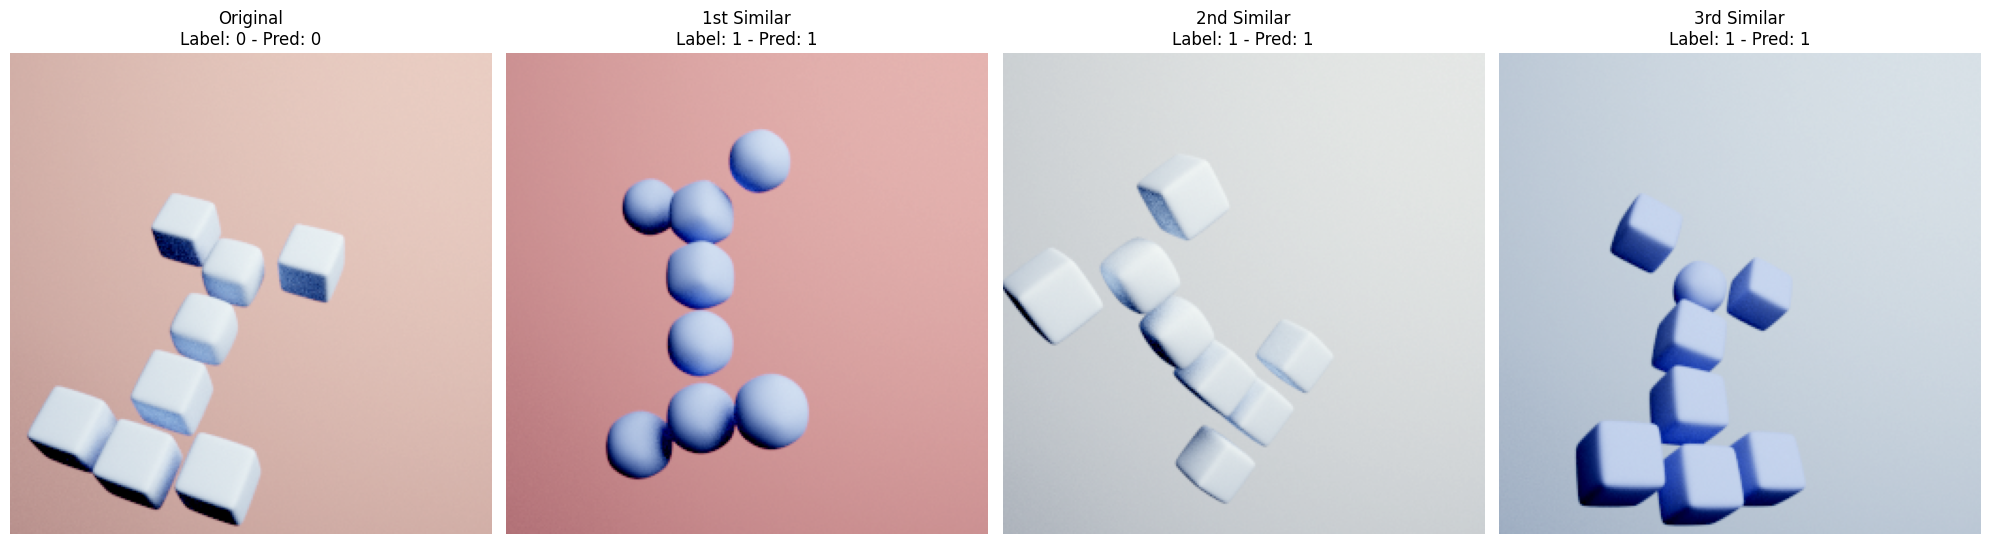

In [33]:
plot_similar(ds, explanation, x_ref)

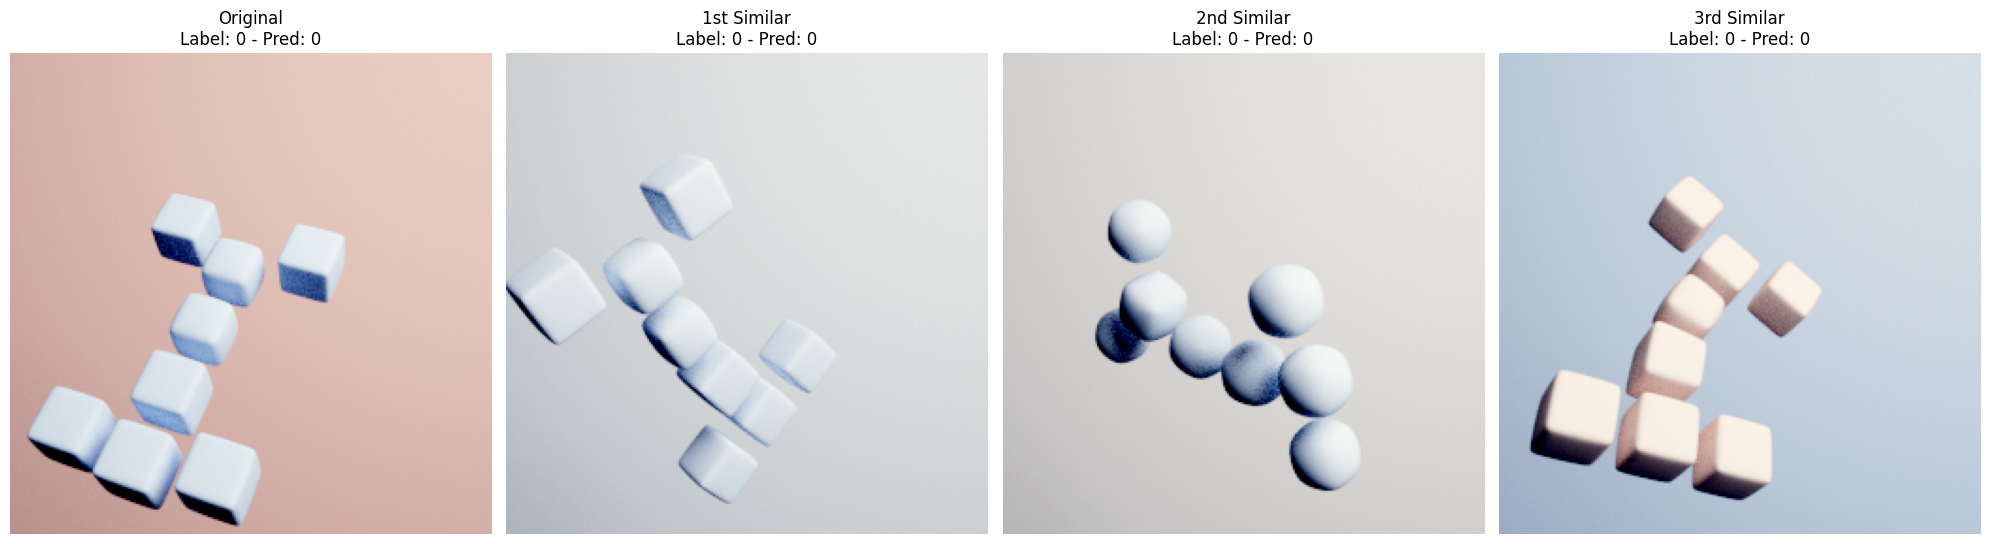

In [ ]:
#plot_similar(ds, explanation, x_ref)